In [1]:
import pandas as pd
import numpy as np
from datetime import datetime

from setting_for_sda.path_setting import path_list
from setting_for_sda.date_setting import Date_Setting


import lib.stats.stats as st
from lib.utils.file_io import *
from lib.utils.statistics import *
from lib.utils.settings import set_matplotlib
from lib.utils.datetime_handler import calc_rel_period
from lib.visualization.distribution_collector import (calc_top_mid_bottom_tags_prop, compute_proportion_period)
from lib.visualization.plot_generator import PlotGen
from matplotlib import pyplot as plt

import matplotlib as mpl
import lib.visualization.font_setting as font_setting
mpl.rcParams['font.family'] = font_setting.init_font()

import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from scipy.stats import spearmanr



Helvetica /home/mghan/.fonts/Helvetica/Helvetica Oblique.ttf
Registered font name: Helvetica


In [10]:
"""
언어별 ITS (Interrupted Time Series) analysis + Forest plot

각 언어에 대해:
  1. df_proportion 만들기 (해당 언어 데이터)
  2. 지표 계산 (Gini / baseline_share / longtail_share)
  3. N-adjusted ITS regression
  4. level shift 계수(post) + slope change 계수(week:post) 추출
  5. Forest plot으로 시각화

Model:
    metric ~ logN + week + post + week:post
    
    - post (β₂): immediate level shift at GPT launch
    - week:post (β₃): change in slope (trend) after GPT launch
    - logN: covariate to adjust for sample size (matters for Gini-like metrics)
"""
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import statsmodels.formula.api as smf
from matplotlib.patches import Patch


# ---------------- 공통 스타일 ----------------
mpl.rcParams.update({
    "font.family":   "sans-serif",
    "font.size":     9,
    "axes.linewidth": 0.8,
})

COLOR_NEG     = "#2C5F8D"   # significant & negative
COLOR_POS     = "#C0392B"   # significant & positive
COLOR_NONSIG  = "#8A8A8A"


def _pick_color(value, significant):
    if significant and value < 0:
        return COLOR_NEG
    if significant and value > 0:
        return COLOR_POS
    return COLOR_NONSIG


# ---------------- 유틸 ----------------
def gini_coefficient(values):
    x = np.asarray(values, dtype=float)
    x = x[x > 0]
    if x.sum() == 0 or len(x) < 2:
        return 0.0
    x_sorted = np.sort(x)
    n = len(x_sorted)
    index = np.arange(1, n + 1)
    return (2.0 * np.sum(index * x_sorted) - (n + 1) * x_sorted.sum()) / (n * x_sorted.sum())


def compute_N_by_week(df, period_col='rel_week', weight_col='tot_pct'):
    """주차별 질문 수"""
    N = df.groupby(period_col)[weight_col].sum()
    try:
        N.index = N.index.astype(int)
    except (ValueError, TypeError):
        pass
    return N.sort_index()


# ---------------- ITS 회귀 ----------------
def fit_its_with_covariate(metric_series, N_series, cutoff=0):
    """
    Interrupted Time Series regression with logN as covariate.
    
    Model:  metric ~ logN + week + post + week:post
    """
    common = metric_series.index.intersection(N_series.index)
    if len(common) < 20:
        return None
    
    df = pd.DataFrame({
        'value': metric_series.loc[common].values,
        'logN':  np.log(N_series.loc[common].values),
        'week':  np.array(common, dtype=float),
    })
    df['post'] = (df['week'] >= cutoff).astype(int)
    
    if df['value'].std() == 0 or df['logN'].std() == 0:
        return None
    
    try:
        model = smf.ols('value ~ logN + week + post + week:post', data=df).fit()
    except Exception:
        return None
    
    return {
        'level_shift':       model.params.get('post', np.nan),
        'level_shift_se':    model.bse.get('post', np.nan),
        'level_shift_pval':  model.pvalues.get('post', np.nan),
        'slope_change':      model.params.get('week:post', np.nan),
        'slope_change_se':   model.bse.get('week:post', np.nan),
        'slope_change_pval': model.pvalues.get('week:post', np.nan),
        'logN_coef':         model.params.get('logN', np.nan),
        'r_squared':         model.rsquared,
        'n_obs':             len(df),
    }


# ---------------- 언어별 ITS 수집 ----------------
def collect_its_by_language(language_data_dict,
                             metric_fn=None,
                             metric_name='gini',
                             cutoff=0):
    """각 언어에 대해 ITS 회귀를 돌리고 결과 DataFrame 반환."""
    if metric_fn is None:
        def metric_fn(df):
            rows = {}
            for w, grp in df.groupby('rel_week'):
                rows[w] = gini_coefficient(grp['proportion'].values)
            s = pd.Series(rows).sort_index()
            try:
                s.index = s.index.astype(int)
            except (ValueError, TypeError):
                pass
            return s
    
    results = []
    for lang, (df_proportion, N_series) in language_data_dict.items():
        metric_s = metric_fn(df_proportion)
        summary = fit_its_with_covariate(metric_s, N_series, cutoff=cutoff)
        if summary is None:
            print(f"  [Skip] {lang}: insufficient data or variance")
            continue
        
        results.append({
            'language': lang,
            'level_shift':         summary['level_shift'],
            'level_shift_se':      summary['level_shift_se'],
            'level_shift_ci_low':  summary['level_shift'] - 1.96 * summary['level_shift_se'],
            'level_shift_ci_high': summary['level_shift'] + 1.96 * summary['level_shift_se'],
            'level_shift_pval':    summary['level_shift_pval'],
            'slope_change':         summary['slope_change'],
            'slope_change_se':      summary['slope_change_se'],
            'slope_change_ci_low':  summary['slope_change'] - 1.96 * summary['slope_change_se'],
            'slope_change_ci_high': summary['slope_change'] + 1.96 * summary['slope_change_se'],
            'slope_change_pval':    summary['slope_change_pval'],
            'logN_coef': summary['logN_coef'],
            'r_squared': summary['r_squared'],
            'n_obs':     summary['n_obs'],
        })
    
    return pd.DataFrame(results)


# ---------------- 정렬 헬퍼 ----------------
def _sort_df(df, sort_by, predefined_order, sort_col='level_shift'):
    if sort_by == 'coef':
        return df.sort_values(sort_col).reset_index(drop=True)
    if sort_by == 'language':
        return df.sort_values('language').reset_index(drop=True)
    if sort_by == 'predefined' and predefined_order is not None:
        order_map = {l: i for i, l in enumerate(predefined_order)}
        df = df.copy()
        df['_order'] = df['language'].map(order_map)
        df = df[df['_order'].notna()].sort_values('_order')
        return df.drop(columns='_order').reset_index(drop=True)
    return df.reset_index(drop=True)


# ---------------- Forest plot (단일 패널) ----------------
def plot_its_forest(its_df,
                    coef_type='level_shift',     # 'level_shift' or 'slope_change'
                    sig_threshold=0.05,
                    sort_by='language',
                    predefined_order=None,
                    title=None,
                    xlabel=None,
                    figsize=(8, 10),
                    save_path=None):
    """Forest plot: 언어별 ITS 계수 + 95% CI"""
    coef_col    = coef_type
    ci_low_col  = f"{coef_type}_ci_low"
    ci_high_col = f"{coef_type}_ci_high"
    pval_col    = f"{coef_type}_pval"
    
    df = _sort_df(its_df, sort_by, predefined_order, sort_col=coef_col)
    df['significant'] = df[pval_col] < sig_threshold
    
    n = len(df)
    y_pos = range(n)
    
    fig, ax = plt.subplots(figsize=figsize)
    
    colors = [_pick_color(row[coef_col], row['significant'])
              for _, row in df.iterrows()]
    
    for i, (_, row) in enumerate(df.iterrows()):
        ax.plot([row[ci_low_col], row[ci_high_col]], [i, i],
                color=colors[i], lw=1.2)
        ax.plot(row[coef_col], i, "o", color=colors[i],
                markersize=7, markeredgecolor="white", markeredgewidth=0.5)
    
    ax.axvline(0, color="0.55", lw=0.6, ls="--")
    ax.set_yticks(y_pos)
    ax.set_yticklabels(df['language'])
    ax.invert_yaxis()
    
    if xlabel is None:
        xlabel = ("Level shift at GPT launch (β₂)" if coef_type == 'level_shift'
                  else "Slope change after GPT launch (β₃, per week)")
    if title is None:
        nice_name = ("immediate level shift (β₂)" if coef_type == 'level_shift'
                     else "trend change (β₃)")
        title = f"Language-specific GPT effect on documentation activity\n(ITS, {nice_name})"
    
    ax.set_xlabel(xlabel)
    ax.set_title(title, loc="left", fontweight="bold")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    
    if coef_type == 'level_shift':
        neg_lbl, pos_lbl = "decreased", "increased"
    else:
        neg_lbl, pos_lbl = "growth slowed", "growth accelerated"
    
    legend = [
        Patch(facecolor=COLOR_NEG,    label=f"p < {sig_threshold}, {neg_lbl}"),
        Patch(facecolor=COLOR_POS,    label=f"p < {sig_threshold}, {pos_lbl}"),
        Patch(facecolor=COLOR_NONSIG, label=f"p ≥ {sig_threshold}"),
    ]
    ax.legend(handles=legend, loc="lower right", fontsize=8)
    
    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
        print(save_path)
    return fig, ax


# ---------------- Forest plot (두 패널 결합) ----------------
def plot_its_forest_combined(its_df,
                              sort_by='language',
                              predefined_order=CONSTANTS.languages_from2020to2022,
                              sig_threshold=0.05,
                              figsize=(13, 10),
                              save_path=None,
                              suptitle=("Language-specific GPT effect : Gini Coefficient\n"
                                        "(N-adjusted ITS regression)")):
    """level_shift (β₂)와 slope_change (β₃)를 나란히 두 panel forest plot으로."""
    df = _sort_df(its_df, sort_by, predefined_order, sort_col='level_shift')
    n = len(df)
    y_pos = range(n)
    
    fig, axes = plt.subplots(1, 2, figsize=figsize, sharey=True)
    
    panels = [
        {
            'ax':      axes[0],
            'coef':    'level_shift',
            'ci_low':  'level_shift_ci_low',
            'ci_high': 'level_shift_ci_high',
            'pval':    'level_shift_pval',
            'xlabel':  'Level shift at GPT launch (β₂)',
            'title':   'Immediate effect (β₂)',
            'neg_lbl': 'decreased',
            'pos_lbl': 'increased',
        },
        {
            'ax':      axes[1],
            'coef':    'slope_change',
            'ci_low':  'slope_change_ci_low',
            'ci_high': 'slope_change_ci_high',
            'pval':    'slope_change_pval',
            'xlabel':  'Slope change after GPT (β₃, per week)',
            'title':   'Trend change (β₃)',
            'neg_lbl': 'growth slowed',
            'pos_lbl': 'growth accelerated',
        },
    ]
    
    for p in panels:
        ax = p['ax']
        
        colors = [_pick_color(row[p['coef']], row[p['pval']] < sig_threshold)
                  for _, row in df.iterrows()]
        
        for i, (_, row) in enumerate(df.iterrows()):
            ax.plot([row[p['ci_low']], row[p['ci_high']]], [i, i],
                    color=colors[i], lw=1.2)
            ax.plot(row[p['coef']], i, "o", color=colors[i],
                    markersize=7, markeredgecolor="white", markeredgewidth=0.5)
        
        ax.axvline(0, color="0.55", lw=0.6, ls="--")
        ax.set_xlabel(p['xlabel'])
        ax.set_title(p['title'], loc="left", fontweight="bold", fontsize=10)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        
        legend = [
            Patch(facecolor=COLOR_NEG,    label=f"p < {sig_threshold}, {p['neg_lbl']}"),
            Patch(facecolor=COLOR_POS,    label=f"p < {sig_threshold}, {p['pos_lbl']}"),
            Patch(facecolor=COLOR_NONSIG, label=f"p ≥ {sig_threshold}"),
        ]
        ax.legend(handles=legend, loc="lower right", fontsize=8)
    
    axes[0].set_yticks(y_pos)
    axes[0].set_yticklabels(df['language'])
    axes[0].invert_yaxis()
    
    fig.suptitle(suptitle, fontweight="bold", fontsize=11, x=0.02, ha="left", y=1.0)
    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
        print(save_path)
    return fig, axes

In [11]:
language_data = {}
for idx, lang in enumerate(CONSTANTS.languages_from2020to2022) :
    plotgen = PlotGen(idx, 'tag')
    print(f'[Start....] drawing figures for {lang} language')


    df = load_df(plotgen.data_dir, ['cdate' , 'id' , 'tag', 'cnt', 'tot_cnt', 'pct'])
    df = calc_rel_period(df, plotgen.std_date, date_col = 'cdate', period = 7)
    df_proportion = compute_proportion_period(df,period = 'rel_week', type = 'tag', value_col='pct')
    N_series = compute_N_by_week(df_proportion, weight_col='pct')

    language_data[lang] = (df_proportion, N_series.sort_index())

[Start....] drawing figures for python language
[Start....] drawing figures for javascript language
[Start....] drawing figures for java language
[Start....] drawing figures for c# language
[Start....] drawing figures for c++ language
[Start....] drawing figures for c language
[Start....] drawing figures for r language
[Start....] drawing figures for php language
[Start....] drawing figures for swift language
[Start....] drawing figures for kotlin language
[Start....] drawing figures for dart language
[Start....] drawing figures for typescript language
[Start....] drawing figures for go language
[Start....] drawing figures for ruby language
[Start....] drawing figures for rust language
[Start....] drawing figures for scala language
[Start....] drawing figures for julia language
[Start....] drawing figures for matlab language
[Start....] drawing figures for groovy language
[Start....] drawing figures for objective-c language
[Start....] drawing figures for vb.net language
[Start....] dr

./fig/its_forest_combined.png
Saved figures.


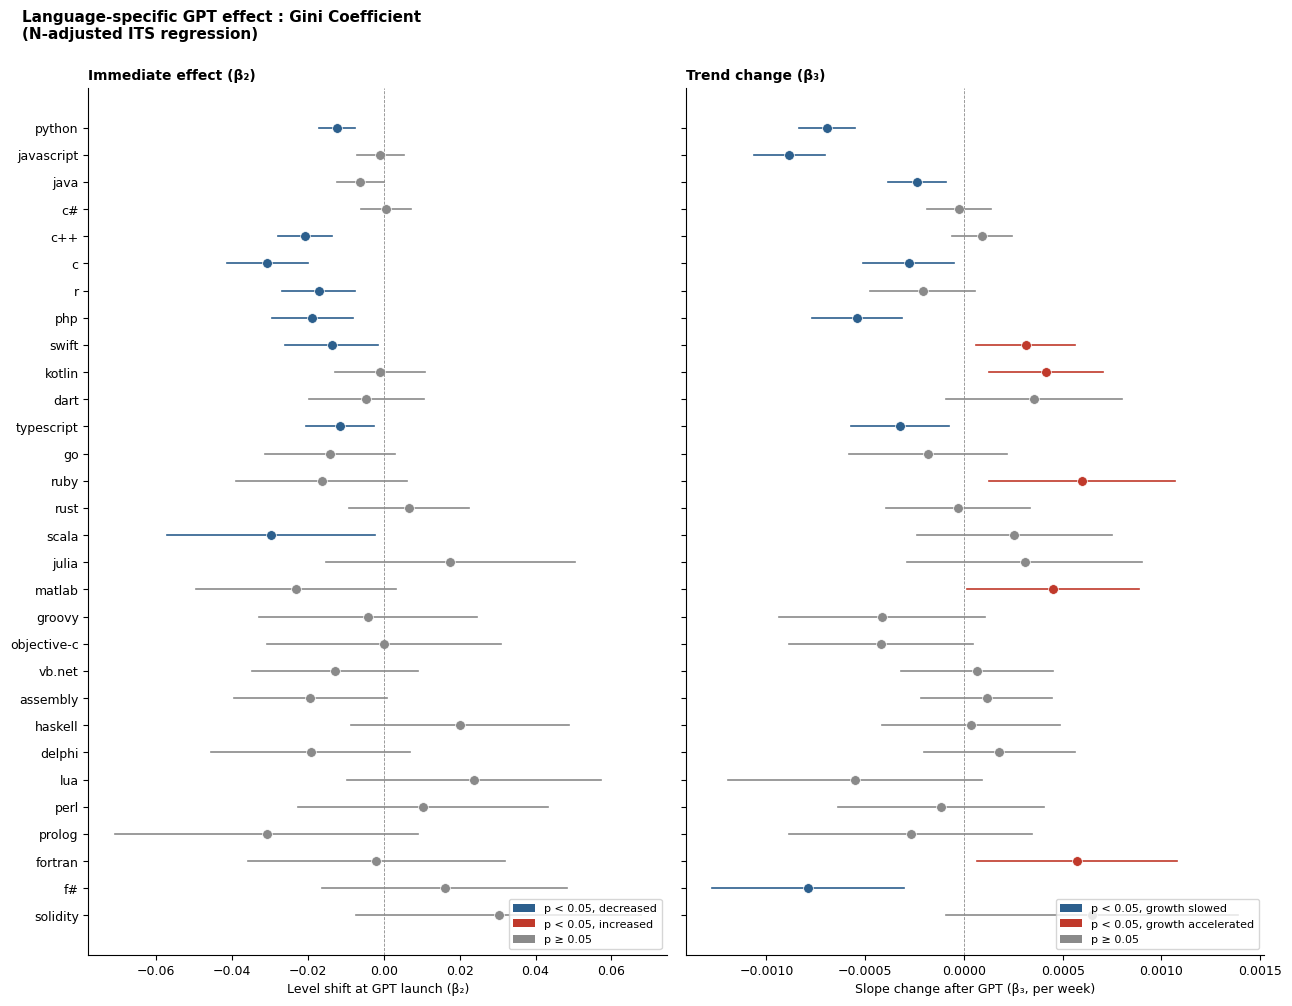

In [12]:
# ITS 수집
print("Collecting per-language ITS (Gini)...")
its_df = collect_its_by_language(language_data, metric_name='gini')

# 단일 panel: level shift (β₂)
# plot_its_forest(its_df,
#                 coef_type='level_shift',     # ← 이거 하나면 됨
#                 sort_by='language',
#                 predefined_order=CONSTANTS.languages_from2020to2022,
#                 title='Per-language N-adjusted Gini: immediate ChatGPT effect',
#                 xlabel='Level shift at week 0 (β₂, N-adjusted)',
#                 save_path='./fig/its_forest_level_shift.png')

# # 단일 panel: slope change (β₃) — 이것도 같이 보고 싶으면
# plot_its_forest(its_df,
#                 coef_type='slope_change',
#                 sort_by='language',
#                 predefined_order=CONSTANTS.languages_from2020to2022,
#                 title='Per-language N-adjusted Gini: trend change',
#                 xlabel='Slope change after ChatGPT (β₃, per week)',
#                 save_path='./fig/its_forest_slope_change.png')

# 두 panel 결합
plot_its_forest_combined(its_df,
                          sort_by='predefined',                              # ← 이거 추가
                          predefined_order=CONSTANTS.languages_from2020to2022,
                          save_path='./fig/its_forest_combined.png')

print("Saved figures.")

In [8]:
its_df
# , sort_by, predefined_order, sort_col='level_shift')

,language,level_shift,level_shift_se,level_shift_ci_low,level_shift_ci_high,level_shift_pval,slope_change,slope_change_se,slope_change_ci_low,slope_change_ci_high,slope_change_pval,logN_coef,r_squared,n_obs
0,python,-0.012260,0.002377,-0.016918,-0.007601,5.022809e-07,-0.000693,0.000072,-0.000834,-0.000553,4.494817e-19,0.066685,0.994194,260
1,javascript,-0.000853,0.003130,-0.006988,0.005281,7.853735e-01,-0.000884,0.000091,-0.001062,-0.000706,3.143791e-19,0.059857,0.990917,260
2,java,-0.006128,0.003205,-0.012409,0.000154,5.700016e-02,-0.000236,0.000075,-0.000383,-0.000089,1.877300e-03,0.067649,0.981129,260
3,c#,0.000568,0.003339,-0.005977,0.007113,8.650516e-01,-0.000024,0.000083,-0.000187,0.000139,7.702699e-01,0.098981,0.979914,260
4,c++,-0.020747,0.003584,-0.027770,-0.013723,2.068853e-08,0.000089,0.000077,-0.000062,0.000241,2.495065e-01,0.078261,0.971907,260
5,c,-0.030621,0.005460,-0.041323,-0.019919,5.311159e-08,-0.000279,0.000118,-0.000511,-0.000048,1.878278e-02,0.069032,0.950913,260
6,r,-0.017161,0.004954,-0.026871,-0.007452,6.234648e-04,-0.000209,0.000136,-0.000475,0.000057,1.254655e-01,0.070280,0.959957,260
7,php,-0.018819,0.005432,-0.029465,-0.008173,6.225683e-04,-0.000542,0.000117,-0.000770,-0.000313,5.351552e-06,0.065400,0.969752,260
8,swift,-0.013696,0.006233,-0.025912,-0.001479,2.890006e-02,0.000312,0.000127,0.000063,0.000561,1.455633e-02,0.078368,0.854987,260
9,kotlin,-0.001095,0.006051,-0.012954,0.010764,8.565619e-01,0.000415,0.000147,0.000127,0.000704,5.142284e-03,0.102900,0.899546,260
